In [1]:
import polars as pl
import matplotlib.pyplot as plt
import numpy as np

In [32]:
class logtransform():
    def __init__(self, pseudocount=0.01):
        self.pseudocount = pseudocount
        self.rounddigits = int(abs(np.log(pseudocount)))

    def __call__(self, x):
        return np.log(x + self.pseudocount)

    def reverse(self, x):
        return np.round(np.exp(x) - self.pseudocount, self.rounddigits)
    
log_norm = logtransform(pseudocount=1)

In [17]:
human_tpm = pl.read_csv('/scratch/tsoies-Expression/GENA_LM/downstream_tasks/expression_prediction/datasets/data/multi_species_rna_geo_artem/GCF_000001405.40/tpm/ENCSR161RSX.csv', has_header=False) \
            .transpose(column_names=['gene', 'tpm']) \
            .with_columns(gene = pl.col('gene').str.to_lowercase())
mouse_tpm = pl.read_csv('/scratch/tsoies-Expression/GENA_LM/downstream_tasks/expression_prediction/datasets/data/multi_species_rna_geo_artem/GCF_000001635.27/tpm/SRX28488332.csv', has_header=False) \
            .transpose(column_names=['gene', 'tpm']) \
            .with_columns(gene = pl.col('gene').str.to_lowercase())

In [18]:
mouse_tpm

gene,tpm
str,str
"""0610005c13rik""","""0.027987"""
"""0610006l08rik""","""0.0"""
"""0610009e02rik""","""0.696228"""
"""0610009l18rik""","""1.153366"""
"""0610010k14rik""","""1.870966"""
…,…
"""n-tygta6""","""0.0"""
"""n-tygta7""","""0.0"""
"""n-tygta8""","""0.0"""


In [19]:
human_tpm

gene,tpm
str,str
"""a1bg""","""3.097954"""
"""a1bg-as1""","""3.460246"""
"""a1cf""","""0.0"""
"""a2m""","""0.0"""
"""a2m-as1""","""0.083113"""
…,…
"""zyx""","""0.0"""
"""zyx""","""0.0"""
"""zyx-2""","""0.0"""


In [ ]:
human_tpm = pl.read_csv('/scratch/tsoies-Expression/GENA_LM/downstream_tasks/expression_prediction/datasets/data/multi_species_rna_geo_artem/GCF_000001405.40/tpm/ENCSR161RSX.csv', has_header=False) \
        .transpose(column_names=['gene', 'tpm']) \
        .with_columns(gene = pl.col('gene').str.to_lowercase())
        
mouse_tpm = pl.read_csv('/scratch/tsoies-Expression/GENA_LM/downstream_tasks/expression_prediction/datasets/data/multi_species_rna_geo_artem/GCF_000001635.27/tpm/SRX28488332.csv', has_header=False) \
        .transpose(column_names=['gene', 'tpm']) \
        .with_columns(gene = pl.col('gene').str.to_lowercase())
        
df = human_tpm.join(mouse_tpm, how='inner', on='gene')\
        .rename({'tpm':'human_tpm', 'tpm_right':'mouse_tpm'})\
        .cast({'human_tpm': pl.Float64, 'mouse_tpm':pl.Float64})\
        .with_columns(human_tpm=pl.col('human_tpm').map_elements(log_norm),
                        mouse_tpm=pl.col('mouse_tpm').map_elements(log_norm))

Text(0.5, 1.0, 'mouse - human expression corr: 0.52')

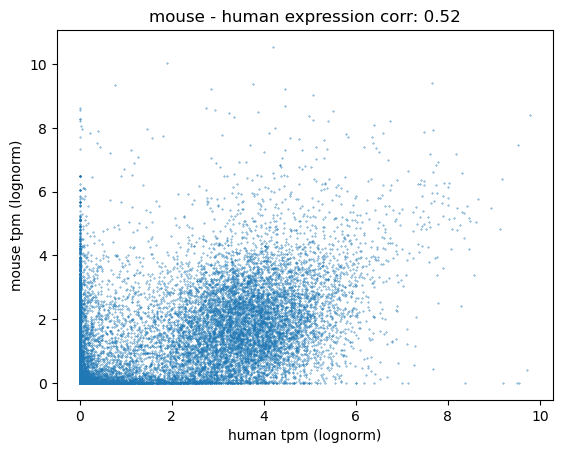

In [49]:
plt.scatter(x=df['human_tpm'], y=df['mouse_tpm'], s=0.1)
plt.xlabel('human tpm (lognorm)')
plt.ylabel('mouse tpm (lognorm)')
plt.title(f"mouse - human expression corr: {round(df.select(['human_tpm', 'mouse_tpm']).corr()[0, 1], 2)}")

In [ ]:
import random
import os

def generate_random_numbers_file(n, a, b, filename='random_numbers.txt', 
                                integer=True, seed=None):

    if n <= 0:
        raise ValueError("N must be a positive integer.")
    if a > b:
        raise ValueError("A must be less than or equal to B.")
    if seed is not None:
        random.seed(seed)

    # Generate random numbers
    if integer:
        numbers = [random.randint(int(a), int(b)) for _ in range(n)]
    else:
        numbers = [random.uniform(a, b) for _ in range(n)]

    # Write to file
    with open(filename, 'a') as f:
        for num in numbers:
            f.write(f"{num}\n")

    return os.path.abspath(filename)

In [7]:
generate_random_numbers_file(1_000, 2, 100, '/scratch/tsoies-atacseq/qnorm/dist/reference.txt', integer=True)

'/scratch/tsoies-atacseq/qnorm/dist/reference.txt'